# TP5: Green ACO pour MAX-SAT 

## **Equipe :** Orama

**Membres :**
- AOUNI Nazim Abdeerhmane
- ELBAR Nour El Imane
- KHALED Adriane Anis
- MOUSSOUS Billel
- OGAB Maroua
- SMARA Rayane Rahmat Errahmane
- SOUALAH MOHAMMED Zakaria


# 1. Description de la Méthode

## 1.1 Rappel: ACO pour MAX-SAT 

L'**Ant Colony Optimisation** maintient une **matrice de phéromones** $\tau$ où $\tau[v][b]$ encode la désirabilité d'assigner la valeur booléenne $b$ à la variable $v$. Chaque itération, un opérateur modifie l'assignation courante et met à jour la phéromone pour renforcer les bonnes assignations.

## 1.2 Green ACO 

## 1.2 Green ACO — Vue d'ensemble de la méthode complète

Le passage au Green ACO introduit plusieurs niveaux d'amélioration par rapport à l'ACO standard. L'idée centrale est de **sélectionner dynamiquement l'opérateur qui maximise le gain de qualité par joule consommé**.

### 1.2.1 L'ordonnanceur EI/J (Expected Improvement per Joule)

Le scheduler apprend quel opérateur est le plus efficace :

$$\text{EI/J}(o) = \frac{\mathbb{E}[\Delta f(o)]}{\mathbb{E}[E(o)]}$$

Les statistiques sont maintenues par **EWMA** (Exponentially Weighted Moving Average) avec facteur de lissage $\alpha $ qui controle le tradeoff entre les appels récents et les plus anciens :

$$\mu_{\Delta f} \leftarrow \alpha\,\mu_{\Delta f} + (1-\alpha)\,\Delta f_t$$
$$\mu_{\ln E} \leftarrow \alpha\,\mu_{\ln E} + (1-\alpha)\,\ln(E_t)$$

Le **Thompson Sampling** injecte une exploration contrôlée, au lieu d'utiliser directement la moyenne, on échantillonne depuis la distribution apprise :

$$\widetilde{\Delta f} \sim \mathcal{N}(\mu_{\Delta f},\, \sigma^2_{\Delta f}) \qquad \widetilde{E} \sim \text{LogNormal}(\mu_{\ln E},\, \sigma^2_{\ln E})$$

Une **pénalité budgétaire** décourage les opérateurs coûteux quand le budget restant est faible :

$$\pi(o, B) = \frac{B}{B + \mathbb{E}[\widetilde{E}(o)]}$$

Score de sélection final :

$$\Phi(o) = \frac{\widetilde{\Delta f}}{\widetilde{E}} \times \pi(o, B) \qquad \Rightarrow \qquad o^* = \arg\max_{o}\,\Phi(o)$$

### 1.2.2 Autres améliorations

| Amélioration | Description | Impact observé |
|---|---|---|
| **Profiling dual-régime** | Avant toute exécution, chaque opérateur est profilé sur chaque instance en régime `easy` (q₀=0.5, beaucoup de clauses unsat) et `hard` (q₀=0.95, quasi-optimal). Les quatre paramètres EWMA ($\mu_{\Delta f}$, $\sigma_{\Delta f}$, $\mu_{\ln E}$, $\sigma_{\ln E}$) sont sauvés et injectés en début de run. | Priors calibrés dès l'itération 1 |
| **Garde anti-dépassement** | Un opérateur est inéligible si son coût estimé dépasse le budget restant d'un facteur $F_{\text{overrun}}$   | Évite les dépassements catastrophiques observés (+776% d'overrun évité en min-fill/400J) |
| **MAJ phéromone sparse** | Les opérateurs flip-based ne modifient que $k \ll n$ variables.  | Gain d'énergie sur les opérateurs flip-based |
| **Mise à jour frugale (frugal skip)** | En phase de stagnation (moyenne des $\Delta f$ sur les $W=10$ dernières itérations $< \varepsilon = 0.5$), la MAJ de phéromone est sautée. Les phéromones ne sont pas renforcées sur des solutions qui stagnent. | 17.5–26.9% de mises à jour économisées |
| **Évaporation adaptative** | Deux niveaux de taux d'évaporation selon l'état de la recherche : $\rho_{\text{base}} = 0.1$ en recherche normale (oubli standard), $\rho_{\text{stagnant}} = 0.02$ quand la stagnation est détectée (oubli lent pour préserver les meilleures pistes apprises). | Meilleure exploitation en fin de run |
| **Caching inter-budgets** | La matrice de phéromones apprise sur un budget $B_1$ est réutilisée comme point de départ pour le budget $B_2 > B_1$ sur la même instance. Mise à jour douce : $\tau \leftarrow (1-\rho_{\text{cache}})\,\tau + \delta_{\text{gain}}$, où $\delta_{\text{gain}} = \Delta f / n_{\text{clauses}}$ (uniquement si la run a progressé, évite de renforcer une stagnation). | Warm-start informé pour les grands budgets |
| **Arrêt anticipé** | Stop si : (1) le meilleur score ne progresse pas depuis `best_stagnation_limit` itérations consécutives, **et** (2) clauses non satisfaites $\leq 0.5\% \times n_{\text{clauses}}$. Budget restant non consommé. | Jusqu'à +500J économisés (vote/2000J) |

---

## 1.3 Pseudo-code de la méthode complète

```
GREEN-ACO(formula, n_vars, energy_budget, operator_profiles):

  ── Initialisation ──────────────────────────────────────────────────
  pheromone ← [[τ₀, τ₀]] × n_vars
  η         ← heuristique (fréquence des littéraux dans les clauses)
  
  Pour chaque opérateur o :
    blend ← f(qualité_initiale)            # régime easy/hard
    op_stats[o].seed_from_profile(         # priors calibrés
        mean_cost_j, std_cost_j,           #   ← énergie depuis CSV
        mean_df, std_df                    #   ← gain qualité depuis CSV
    )
  
  best_assignment ← build_greedy(pheromone, η, q₀=0.95)
  budget          ← energy_budget

  ── Boucle principale ───────────────────────────────────────────────
  TANT QUE budget > 0 :

    ── Sélection de l'opérateur ──────────────────────────────────────
    SI warm-up (certains opérateurs jamais appelés) :
      o* ← opérateur non appelé aléatoire (si coût estimé ≤ budget × F_overrun)
    SINON :
      eligible ← { o | E[E(o)] ≤ budget × F_overrun }   # garde overrun
      POUR chaque o dans eligible :
        Δf̃  ~ 𝒩(μ_Δf,  σ²_Δf)                         # Thompson sampling
        Ẽ   ~ LogNormal(μ_lnE, σ²_lnE)
        π   ← budget / (budget + E[Ẽ])                  # pénalité budget
        Φ(o) ← (Δf̃ / Ẽ) × π
      o* ← argmax Φ(o)

    ── Exécution & mesure ────────────────────────────────────────────
    (new_assignment, Δf), energy_j ← measure_energy(o*(current_assignment))
    budget  -= energy_j
    op_stats[o*].update(Δf, energy_j)     # EWMA update

    ── Mise à jour phéromone ─────────────────────────────────────────
    SI o* est flip-based (WalkSAT, Bandit) :
      pheromone_sparse_update(            # O(k) — seulement vars flippées
          previous_assignment, new_assignment, score)
    SINON :
      pheromone_full_update(new_assignment, score)   # O(n)

    ── Mise à jour du meilleur ───────────────────────────────────────
    SI score(new_assignment) > score(best_assignment) :
      best_assignment ← new_assignment

    ── Conditions d'arrêt anticipé ───────────────────────────────────
    SI qualité > 99.5%  →  STOP  (plateau atteint, budget économisé)
    SI stagnation_tracker.is_stagnant()  →  ajuster ρ, continuer
    SI consecutive_no_improve > best_stagnation_limit  →  STOP

  RETOURNER best_assignment, stats
```

## 1.3 Tableau des opérateurs — coût moyen & qualité apportée

Le tableau ci-dessous synthétise les caractéristiques de chaque opérateur mesurées lors du profiling (n_runs=10, 4 instances × 2 régimes).

| Opérateur | Mécanisme |
|---|---|
| **WalkSAT** | Cible les clauses non satisfaites : flip greedy (max clauses satisfaites) ou aléatoire avec probabilité $p_{\text{noise}}$ | 
| **Focused VNS** | Classe les variables par (nb clauses unsat) × (signal phéromone), flip les top-$k$ plus problématiques | 
| **Clause Restart Greedy** | Reconstruction partielle guidée : réassigne greedy les variables les plus impliquées dans les clauses unsat | 


In [41]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

OPERATOR_POOL_STATS = ["focused_vns", "walksat", "clause_restart_greedy"]

def shorten(name):
    name = name.replace("decision-tree-", "dt-").replace("-un-formula_0.8_2021_atleast_15_max-3_reduced_incomplete_tree", "")
    name = name.replace("min-fill-MinFill_R0_", "minfill-")
    return name[:28]

try:
    df_prof = pd.read_csv("operator_profiles.csv")
    df_prof = df_prof[df_prof["operator"].isin(OPERATOR_POOL_STATS)]

    for regime in df_prof["regime"].unique():
        df_r = df_prof[df_prof["regime"] == regime].copy()
        df_r["instance"] = df_r["benchmark"].apply(shorten)
        df_r["qualite_moy_pct"] = (df_r["mean_df"] / df_r["n_clauses"] * 100).round(2)

        display_df = df_r[[
            "instance", "operator",
            "mean_cost_j",
            "mean_df", "qualite_moy_pct",
        ]].sort_values(["instance", "mean_cost_j"]).reset_index(drop=True)

        display_df.columns = [
            "Instance", "Opérateur",
            "Coût moyen (J)",
            "Δf moyen", "Qualité moy. (%)",
        ]

        label = "facile — q₀=0.5" if regime == "easy" else "difficile — q₀=0.95"
        print(f"{'='*70}")
        print(f"  Régime {regime.upper()} ({label})")
        print(f"{'='*70}")
        display(display_df.style
                .background_gradient(subset=["Coût moyen (J)"],  cmap="YlOrRd")
                .background_gradient(subset=["Δf moyen"],        cmap="YlGn")
                .background_gradient(subset=["Qualité moy. (%)"],cmap="YlGn")
                .format({
                    "Coût moyen (J)":   "{:.3f}",
                    "Δf moyen":         "{:.2f}",
                    "Qualité moy. (%)": "{:.2f}%",
                })
                .set_caption(f"Profiling régime {regime} — coût et qualité par (instance, opérateur)"))

except FileNotFoundError:
    print("⚠ operator_profiles.csv introuvable — relancer la cellule de profiling dans le notebook TP5")

  Régime EASY (facile — q₀=0.5)


,Instance,Opérateur,Coût moyen (J),Δf moyen,Qualité moy. (%)
0,dt-car,focused_vns,18.792,856.90,0.78%
1,dt-car,walksat,44.935,2698.50,2.45%
2,dt-car,clause_restart_greedy,1501.061,4037.90,3.66%
3,dt-soybean,focused_vns,20.126,445.10,0.50%
4,dt-soybean,walksat,48.103,921.60,1.03%
5,dt-soybean,clause_restart_greedy,1597.764,3525.70,3.92%
6,dt-vote,focused_vns,17.452,235.40,0.30%
7,dt-vote,walksat,38.555,839.40,1.08%
8,dt-vote,clause_restart_greedy,1146.963,3568.20,4.57%
9,minfill-myciel5,focused_vns,22.676,17.80,0.02%


  Régime HARD (difficile — q₀=0.95)


,Instance,Opérateur,Coût moyen (J),Δf moyen,Qualité moy. (%)
0,dt-car,focused_vns,19.431,8.60,0.01%
1,dt-car,walksat,37.985,51.10,0.05%
2,dt-car,clause_restart_greedy,1450.439,1163.00,1.06%
3,dt-soybean,focused_vns,31.754,392.50,0.44%
4,dt-soybean,walksat,55.682,2283.90,2.54%
5,dt-soybean,clause_restart_greedy,1310.112,2913.30,3.24%
6,dt-vote,focused_vns,21.756,211.40,0.27%
7,dt-vote,walksat,41.949,1104.90,1.42%
8,dt-vote,clause_restart_greedy,545.923,2356.90,3.02%
9,minfill-myciel5,focused_vns,19.470,13.20,0.01%


## 1.4 Tests Statistiques

**Kruskal-Wallis**, **Mann-Whitney U**, **Wilcoxon** sur les Δf produits par chaque opérateur (données extraites du profiling, n=10 runs × 4 instances = 40 obs. par opérateur).



  TESTS STATISTIQUES — Comparaison des opérateurs (Δf)

Opérateurs : ['clause_restart_greedy', 'focused_vns', 'walksat']
Observations par opérateur (nb lignes profiling) : [8, 8, 8]

 Kruskal-Wallis (H=14.0850, p=0.0009)
  → Au moins un opérateur produit une distribution de Δf significativement différente (p<0.05)

 Mann-Whitney U — comparaisons par paires (Δf):
  clause_restart_greedy        vs focused_vns                  : U=64.0, p=0.0002 ✓ sig.
  clause_restart_greedy        vs walksat                      : U=57.0, p=0.0070 ✓ sig.
  focused_vns                  vs walksat                      : U=16.0, p=0.1049   n.s.

 Wilcoxon signed-rank — appariement par (instance, régime):
  clause_restart_greedy        vs focused_vns                  : W=0.0, p=0.0078 ✓ sig.
  clause_restart_greedy        vs walksat                      : W=0.0, p=0.0078 ✓ sig.
  focused_vns                  vs walksat                      : W=0.0, p=0.0078 ✓ sig.


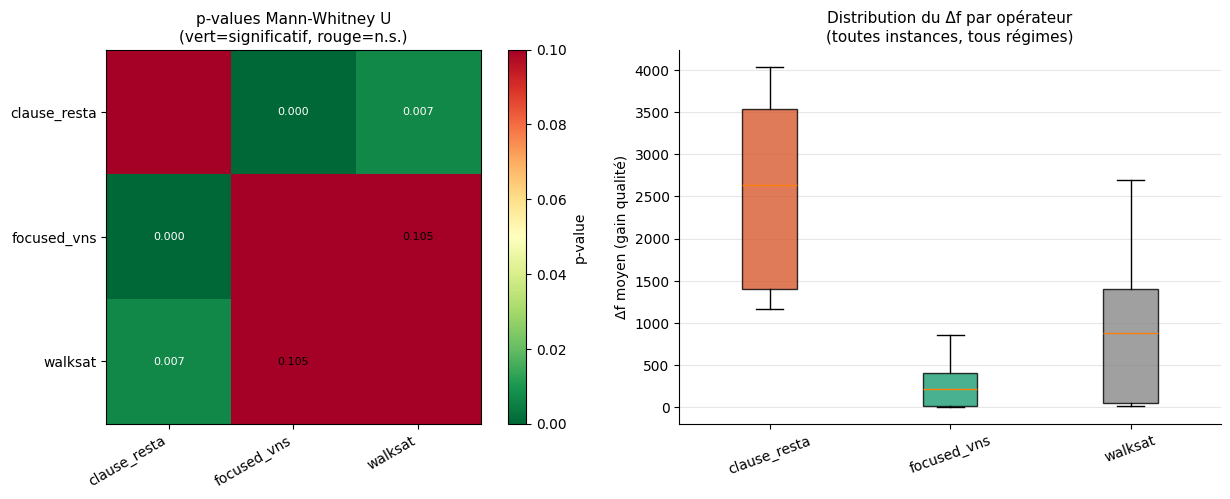


✔ Sauvegardé: fig_stat_tests.png, stat_tests_results.csv


In [80]:
# ════════════════════════════════════════════════════════════════════
# CELLULE C — Tests statistiques sur les opérateurs (depuis profiling)
# ════════════════════════════════════════════════════════════════════
# Utilise operator_profiles.csv (n_runs=10 × 4 instances = 40 obs/opérateur)
# Tests : Kruskal-Wallis (3 groupes), Mann-Whitney U (pairwise), Wilcoxon

from scipy import stats as sp_stats
from itertools import combinations

OPERATOR_POOL_STATS = ["focused_vns", "walksat", "clause_restart_greedy"]

def run_statistical_tests(csv_path="operator_profiles.csv"):
    if not os.path.exists(csv_path):
        print("⚠ operator_profiles.csv non trouvé")
        return

    df_p = pd.read_csv(csv_path)
    df_p = df_p[df_p["operator"].isin(OPERATOR_POOL_STATS)]

    print("="*65)
    print("  TESTS STATISTIQUES — Comparaison des opérateurs (Δf)")
    print("="*65)

    op_groups = {}
    for op, grp in df_p.groupby("operator"):
        op_groups[op] = grp["mean_df"].values

    ops_list = list(op_groups.keys())
    print(f"\nOpérateurs : {ops_list}")
    print(f"Observations par opérateur (nb lignes profiling) : {[len(v) for v in op_groups.values()]}")

    # ── 1. Kruskal-Wallis ────────────────────────────────────────────────────
    H, p_kruskal = sp_stats.kruskal(*op_groups.values())
    print(f"\n Kruskal-Wallis (H={H:.4f}, p={p_kruskal:.4f})")
    if p_kruskal < 0.05:
        print("  → Au moins un opérateur produit une distribution de Δf significativement différente (p<0.05)")
    else:
        print("  → Pas de différence significative entre opérateurs (p≥0.05)")

    # ── 2. Mann-Whitney U pairwise ───────────────────────────────────────────
    print("\n Mann-Whitney U — comparaisons par paires (Δf):")
    mw_results = []
    for op1, op2 in combinations(ops_list, 2):
        u, p = sp_stats.mannwhitneyu(op_groups[op1], op_groups[op2], alternative="two-sided")
        sig = "✓ sig." if p < 0.05 else "  n.s."
        print(f"  {op1:<28s} vs {op2:<28s} : U={u:.1f}, p={p:.4f} {sig}")
        mw_results.append({"op1": op1, "op2": op2, "U": u, "p_value": p, "significant": p < 0.05})

    # ── 3. Wilcoxon signed-rank ──────────────────────────────────────────────
    print("\n Wilcoxon signed-rank — appariement par (instance, régime):")
    for op1, op2 in combinations(ops_list, 2):
        grp1 = df_p[df_p["operator"] == op1].sort_values(["benchmark", "regime"])["mean_df"].values
        grp2 = df_p[df_p["operator"] == op2].sort_values(["benchmark", "regime"])["mean_df"].values
        min_len = min(len(grp1), len(grp2))
        if min_len >= 5:
            try:
                w, p = sp_stats.wilcoxon(grp1[:min_len], grp2[:min_len], zero_method="pratt")
                sig = "✓ sig." if p < 0.05 else "  n.s."
                print(f"  {op1:<28s} vs {op2:<28s} : W={w:.1f}, p={p:.4f} {sig}")
            except ValueError as e:
                print(f"  {op1} vs {op2} : {e}")

    # ── Visualisations ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Heatmap p-values Mann-Whitney
    ax = axes[0]
    n_ops = len(ops_list)
    p_matrix = np.ones((n_ops, n_ops))
    for r in mw_results:
        i, j = ops_list.index(r["op1"]), ops_list.index(r["op2"])
        p_matrix[i][j] = r["p_value"]
        p_matrix[j][i] = r["p_value"]

    im = ax.imshow(p_matrix, cmap="RdYlGn_r", vmin=0, vmax=0.1)
    ax.set_xticks(range(n_ops))
    ax.set_yticks(range(n_ops))
    short_names = [op[:12] for op in ops_list]
    ax.set_xticklabels(short_names, rotation=30, ha="right")
    ax.set_yticklabels(short_names)
    ax.set_title("p-values Mann-Whitney U\n(vert=significatif, rouge=n.s.)", fontsize=11)
    plt.colorbar(im, ax=ax, label="p-value")
    for i in range(n_ops):
        for j in range(n_ops):
            if i != j:
                ax.text(j, i, f"{p_matrix[i,j]:.3f}", ha="center", va="center",
                        fontsize=8, color="white" if p_matrix[i,j] < 0.05 else "black")

    # Boxplot Δf par opérateur
    ax = axes[1]
    data_box = [op_groups[op] for op in ops_list]
    bp = ax.boxplot(data_box, labels=[op[:12] for op in ops_list], patch_artist=True)
    OP_COLORS = ["#D85A30", "#1D9E75", "#888888"]
    for patch, color in zip(bp["boxes"], OP_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_ylabel("Δf moyen (gain qualité)")
    ax.set_title("Distribution du Δf par opérateur\n(toutes instances, tous régimes)", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.savefig("fig_stat_tests.png", dpi=150, bbox_inches="tight")
    plt.show()

    df_mw = pd.DataFrame(mw_results)
    df_mw.to_csv("stat_tests_results.csv", index=False)
    print("\n✔ Sauvegardé: fig_stat_tests.png, stat_tests_results.csv")
    return df_mw

df_stats = run_statistical_tests()

---
# 2. Expériences

## 2.1 Les 4 instances utilisées


| # | Alias | Nom complet | Vars | Clauses | Best known |
|---|---|---|---|---|---|
| 1 | soybean | decision-tree-soybean-un-formula_0.8_2021_atleast_15_max-3_reduced_incomplete_tree | 10 503 | 89 879 | 22 | 
| 2 | min-fill | min-fill-MinFill_R0_myciel5 | 15 416 | 109 371 | 196 | 
| 3 | car | decision-tree-car-un-formula_0.8_2021_atleast_15_max-3_reduced_incomplete_tree | 5 959 | 110 235 | 143 | 
| 4 | vote | decision-tree-vote-un-formula_0.8_2021_atleast_15_max-3_reduced_incomplete_tree | 9 973 | 78 069 | 6 |

## 2.2 Protocole de fine-tuning et meilleurs paramètres

L'optimisation des hyperparamètres est réalisée avec **Optuna** (TPE Sampler, 50 trials), en maximisant le ratio **qualité/joule**.

### Espace de recherche Optuna

| Hyperparamètre | Plage | Rôle |
|---|---|---|
| `alpha_ewma` | [0.5, 0.99] | Facteur de lissage EWMA du scheduler |
| `max_overrun_factor` | [1.0, 3.0] | Tolérance au dépassement de budget par opérateur |
| `stagnation_window` | [5, 20] | Fenêtre de détection de stagnation |
| `stagnation_epsilon` | [0.1, 2.0] | Seuil de stagnation (Δf moyen) |
| `best_stagnation_limit` | [5, 30] | Max itérations sans amélioration du meilleur |
| `plateau_tolerance_pct` | [0.001, 0.02] | Tolérance pour arrêt anticipé |
| `rho_base` | [0.01, 0.3] | Évaporation phéromone (normal) |
| `rho_stagnant` | [0.005, 0.1] | Évaporation phéromone (stagnation) |


In [73]:
import os
import pandas as pd
if os.path.exists("optuna_results.csv"):
    df_optuna = pd.read_csv("optuna_results.csv")
    best_trial = df_optuna.loc[df_optuna["value"].idxmax()]
    param_cols = [c for c in df_optuna.columns if c.startswith("params_")]
    
    best_params = {}
    for col in param_cols:
        best_params[col.replace("params_", "")] = best_trial[col]

    df_best = pd.DataFrame(best_params.items(), columns=["Paramètre", "Valeur"])
    display(df_best.style
            .set_caption(" Meilleurs paramètres — Optuna")
            .hide(axis="index"))

else:
    print("⚠ optuna_results.csv non trouvé — valeurs empiriques TP5 :")
    best_params_default = {
        "alpha_ewma"           : 0.9,
        "max_overrun_factor"   : 1.8,
        "stagnation_window"    : 10,
        "stagnation_epsilon"   : 0.5,
        "best_stagnation_limit": 15,
        "plateau_tolerance_pct": 0.005,
        "rho_base"             : 0.1,
        "rho_stagnant"         : 0.02,
    }
    df_best = pd.DataFrame(best_params_default.items(), columns=["Paramètre", "Valeur"])
    display(df_best.style
            .set_caption("Paramètres empiriques TP5")
            .hide(axis="index"))

Paramètre,Valeur
alpha_ewma,0.632961
best_stagnation_limit,13.000000
max_overrun_factor,1.176985
plateau_tolerance_pct,0.008385
rho_base,0.250334
rho_stagnant,0.038892
stagnation_epsilon,0.185932
stagnation_window,8.000000


## 2.3 Résultats du profiling 

Le profiling mesure pour chaque opérateur, sur chaque instance, en régime `easy` et `hard` :
- Le coût énergétique moyen (Joules)
- Le gain de qualité moyen (Δf)


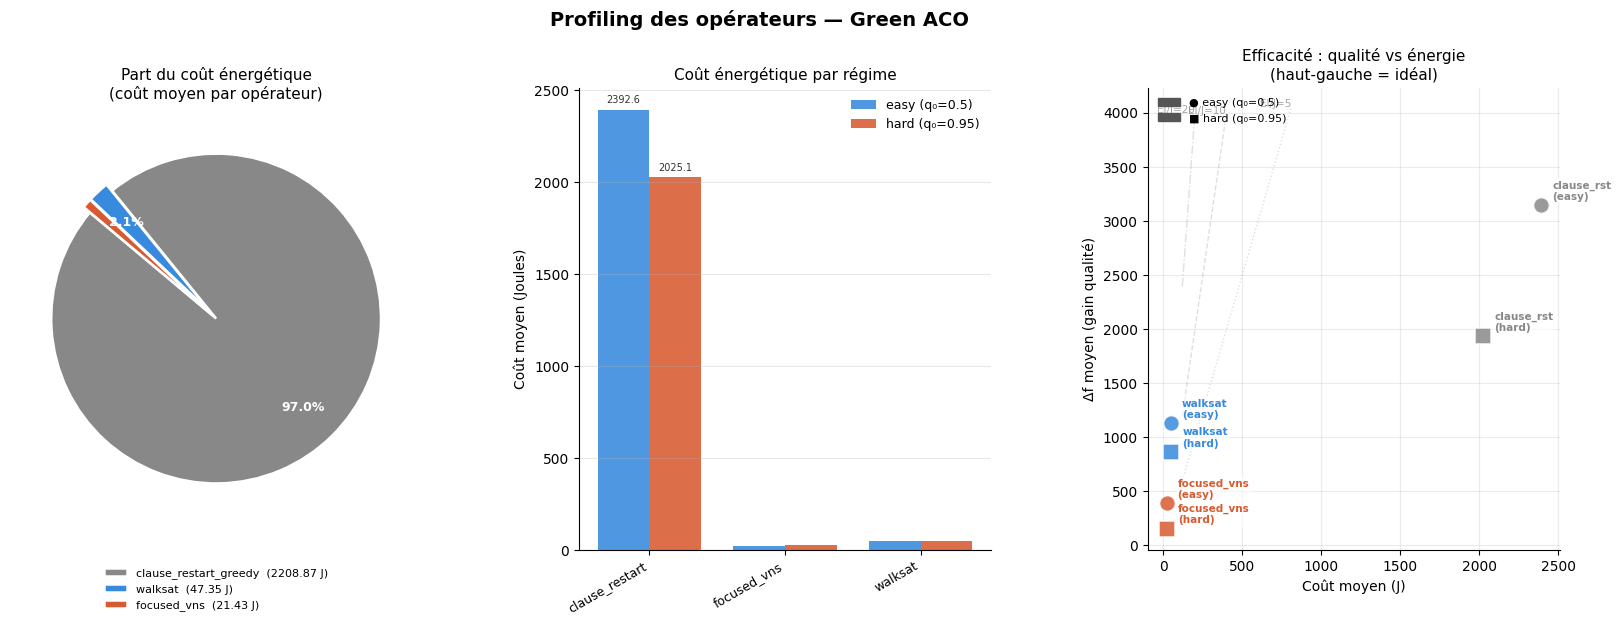

✔ Sauvegardé: fig_profiling.png


In [42]:
# ── Visualisations du profiling ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OPERATOR_POOL_STATS = ["focused_vns", "walksat", "clause_restart_greedy"]

COLORS_OPS = {
    "walksat"              : "#378ADD",
    "focused_vns"          : "#D85A30",
    "clause_restart_greedy": "#888888",
}

if os.path.exists("operator_profiles.csv"):
    df_p = pd.read_csv("operator_profiles.csv")
    df_p = df_p[df_p["operator"].isin(OPERATOR_POOL_STATS)]

    fig = plt.figure(figsize=(20, 6))
    fig.suptitle("Profiling des opérateurs — Green ACO", fontsize=14, fontweight="bold", y=1.01)
    gs = fig.add_gridspec(1, 3, wspace=0.38)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])

    # ── 1. Pie chart — part du coût énergétique ──────────────────────────────
    energy_by_op = df_p.groupby("operator")["mean_cost_j"].mean().sort_values(ascending=False)
    pie_colors   = [COLORS_OPS.get(op, "#aaaaaa") for op in energy_by_op.index]
    explode      = [0.05 if v / energy_by_op.sum() < 0.05 else 0 for v in energy_by_op.values]

    wedges, texts, autotexts = ax0.pie(
        energy_by_op.values,
        labels=None,
        colors=pie_colors,
        autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
        startangle=140,
        explode=explode,
        wedgeprops={"edgecolor": "white", "linewidth": 1.8},
        pctdistance=0.75,
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight("bold")
        at.set_color("white")

    legend_labels = [f"{op}  ({v:.2f} J)" for op, v in energy_by_op.items()]
    ax0.legend(wedges, legend_labels, loc="upper center",
               bbox_to_anchor=(0.5, -0.08), fontsize=8, frameon=False, ncol=1)
    ax0.set_title("Part du coût énergétique\n(coût moyen par opérateur)", fontsize=11, pad=10)

    # ── 2. Bar chart — coût moyen par opérateur et régime ───────────────────
    df_easy = df_p[df_p["regime"] == "easy"].groupby("operator")["mean_cost_j"].mean()
    df_hard = (df_p[df_p["regime"] == "hard"].groupby("operator")["mean_cost_j"].mean()
               if "hard" in df_p["regime"].values else df_easy * 0)

    all_ops = df_easy.index.union(df_hard.index)
    df_easy = df_easy.reindex(all_ops, fill_value=0)
    df_hard = df_hard.reindex(all_ops, fill_value=0)

    x = np.arange(len(all_ops))
    w = 0.38
    b1 = ax1.bar(x - w/2, df_easy.values, w, label="easy (q₀=0.5)",  color="#378ADD", alpha=0.88)
    b2 = ax1.bar(x + w/2, df_hard.values, w, label="hard (q₀=0.95)", color="#D85A30", alpha=0.88)

    short_names = [op.replace("clause_restart_greedy", "clause_restart") for op in all_ops]
    ax1.set_xticks(x)
    ax1.set_xticklabels(short_names, rotation=30, ha="right", fontsize=9)
    ax1.set_ylabel("Coût moyen (Joules)", fontsize=10)
    ax1.set_title("Coût énergétique par régime", fontsize=11)
    ax1.legend(fontsize=9, frameon=False)
    ax1.grid(axis="y", alpha=0.3)
    ax1.spines[["top", "right"]].set_visible(False)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > ax1.get_ylim()[1] * 0.02:
            ax1.text(bar.get_x() + bar.get_width() / 2, h + ax1.get_ylim()[1] * 0.01,
                     f"{h:.1f}", ha="center", va="bottom", fontsize=7, color="#333")

    # ── 3. Scatter — Δf moyen vs coût (efficacité) ──────────────────────────
    all_points = []
    for regime, marker in [("easy", "o"), ("hard", "s")]:
        sub = (df_p[df_p["regime"] == regime]
               .groupby("operator")
               .agg(cost=("mean_cost_j", "mean"), delta_f=("mean_df", "mean"))
               .reset_index())
        for _, row in sub.iterrows():
            all_points.append((row["cost"], row["delta_f"], row["operator"], regime, marker))

    plotted_labels = {}
    for cost, df_val, op, regime, marker in all_points:
        c = COLORS_OPS.get(op, "#888")
        ax2.scatter(cost, df_val, color=c, marker=marker, s=130, alpha=0.85,
                    edgecolors="white", linewidth=1.2, zorder=3)
        label_key = f"{op}-{regime}"
        if label_key not in plotted_labels:
            short_op = op.replace("clause_restart_greedy", "clause_rst")
            ax2.annotate(
                f"{short_op}\n({regime})",
                (cost, df_val),
                textcoords="offset points", xytext=(8, 4),
                fontsize=7.5, color=c, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6),
                zorder=4,
            )
            plotted_labels[label_key] = True

    ax2.set_xlabel("Coût moyen (J)", fontsize=10)
    ax2.set_ylabel("Δf moyen (gain qualité)", fontsize=10)
    ax2.set_title("Efficacité : qualité vs énergie\n(haut-gauche = idéal)", fontsize=11)
    ax2.grid(alpha=0.25)
    ax2.spines[["top", "right"]].set_visible(False)

    x_data_max = max(p[0] for p in all_points) if all_points else 100
    y_data_max = max(p[1] for p in all_points) if all_points else 100
    xr = np.linspace(x_data_max * 0.05, x_data_max * 1.15, 200)
    for eij, ls in [(5, ":"), (10, "--"), (20, "-.")]:
        yr = eij * xr
        mask = yr <= y_data_max * 1.3
        if mask.any():
            ax2.plot(xr[mask], yr[mask], ls=ls, alpha=0.25, color="gray", linewidth=1)
            ax2.text(xr[mask][-1], yr[mask][-1], f"EI/J={eij}",
                     fontsize=7.5, color="gray", alpha=0.7, va="bottom", ha="right")

    legend_handles = [
        mpatches.Patch(color="#555", label="● easy (q₀=0.5)"),
        mpatches.Patch(color="#555", label="■ hard (q₀=0.95)"),
    ]
    ax2.legend(handles=legend_handles, fontsize=8, frameon=False, loc="upper left")

    plt.tight_layout()
    plt.savefig("fig_profiling.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✔ Sauvegardé: fig_profiling.png")

else:
    print("⚠ operator_profiles.csv non trouvé — relancer le profiling depuis le notebook TP5")

## 2.4 Étude d'ablation 

### Configurations testées

L'ablation évalue l'impact de chaque composant de Green ACO :

| Configuration | WalkSAT | FocusedVNS | ClauseRestart | Caching phéromone | Profiling | Green pheromone update | Overrun fix |
|---|---|---|---|---|---|---|---|
| **Full** | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| w/o WalkSAT | — | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| w/o FocusedVNS | ✓ | — | ✓ | ✓ | ✓ | ✓ | ✓ |
| w/o ClauseRestart | ✓ | ✓ | — | ✓ | ✓ | ✓ | ✓ |
| w/o Caching | ✓ | ✓ | ✓ | — | ✓ | ✓ | ✓ |
| w/o Profiling | ✓ | ✓ | ✓ | ✓ | — | ✓ | ✓ |
| w/o Green update | ✓ | ✓ | ✓ | ✓ | ✓ | — | ✓ |
| w/o Overrun fix | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | — |


In [ ]:
# ════════════════════════════════════════════════════════════════════
# CELLULE A — Exécuter l'ablation et sauvegarder les résultats
# ════════════════════════════════════════════════════════════════════
# ⚠ Cette cellule est longue (plusieurs minutes). 
#   Les résultats sont sauvegardés dans ablation_results.csv.
#   Commenter après la première exécution.

import copy

ABLATION_CONFIGS = {
    "full_v4"        : ["walksat", "focused_vns",  "clause_restart_greedy"],
    "no_walksat"     : ["focused_vns",  "clause_restart_greedy"],
    "no_focused_vns" : ["walksat", "clause_restart_greedy"],
    "no_greedy_restart"         : ["walksat", "focused_vns"],
}

ABLATION_OPT_FLAGS = {
    # use_sparse_update    → MAJ phéromone O(k) vs O(n) PAR ITÉRATION
    # use_pheromone_cache  → warm-start INTER-BUDGETS (réutilise tau appris sur B₁ pour B₂)
    # use_profiling        → priors calibrés depuis operator_profiles.csv
    # max_overrun_factor   → garde anti-dépassement budget
    "full_v4"       : {"use_sparse_update": True,  "use_pheromone_cache": True,  "use_profiling": True,  "max_overrun_factor": 1.8},
    "no_sparse_ph"  : {"use_sparse_update": False, "use_pheromone_cache": True,  "use_profiling": True,  "max_overrun_factor": 1.8},
    "no_caching"    : {"use_sparse_update": True,  "use_pheromone_cache": False, "use_profiling": True,  "max_overrun_factor": 1.8},
    "no_profiling"  : {"use_sparse_update": True,  "use_pheromone_cache": True,  "use_profiling": False, "max_overrun_factor": 1.8},
    "no_overrun_fix": {"use_sparse_update": True,  "use_pheromone_cache": True,  "use_profiling": True,  "max_overrun_factor": 9999},
}

ABLATION_RUN = True  # Mettre True pour lancer l'ablation

if ABLATION_RUN:
    ablation_rows = []
    BUDGETS_ABL = [400, 1000, 2000]

    def _collect(config_name, active_ops_str, inst_name, budget, stats, gm):
        """Append one result row."""
        ablation_rows.append({
            "config"         : config_name,
            "active_ops"     : active_ops_str,
            "instance"       : inst_name,
            "budget_j"       : budget,
            "qualite_pct"    : stats["qualite_pct"],
            "energie_joules" : stats["energie_joules"],
            "score_per_joule": gm["score_per_joule"],
            "co2_micrograms" : gm["co2_micrograms"],
            "stopped_reason" : stats["stopped_reason"],
        })

    # ── AXE A : impact de chaque opérateur ──────────────────────────
    # Flags fixes = full_v4 pour isoler uniquement l'effet des opérateurs
    print("Démarrage ablation — AXE A : configurations d'opérateurs\n")
    flags_a = ABLATION_OPT_FLAGS["full_v4"]

    for config_name, active_ops in ABLATION_CONFIGS.items():
        print(f"── Config: {config_name} (ops: {active_ops})")
        for inst in dataset_records:
            formula, n_vars = inst["clauses_list"], inst["vars"]
            inst_name = inst["benchmark"]

            # pheromone cache: None = cold start, reset per instance
            cached_pheromone = None

            for budget in BUDGETS_ABL:
                OPERATOR_POOL_ABL = {k: v for k, v in OPERATOR_POOL.items() if k in active_ops}
                ORIG_POOL = OPERATOR_POOL.copy()
                OPERATOR_POOL.clear()
                OPERATOR_POOL.update(OPERATOR_POOL_ABL)
                try:
                    # pheromone_init=None → cold start on first budget,
                    # deep copy of cached matrix → warm-start on subsequent budgets.
                    # deep copy is critical: green_aco_v4 mutates pheromone in-place,
                    # so without it B₁ and B₂ would share the same list object.
                    _, stats = green_aco_v4(
                        formula, n_vars,
                        inst_benchmark     = inst_name,
                        energy_budget_j    = float(budget),
                        use_sparse_update  = flags_a["use_sparse_update"],
                        max_overrun_factor = flags_a["max_overrun_factor"],
                        pheromone_init     = copy.deepcopy(cached_pheromone),
                    )

                    # green_aco_v4 doesn't return pheromone in stats, but pheromone
                    # is built fresh inside the function from pheromone_init.
                    # To carry the learned matrix forward we rebuild it from stats:
                    # use budget_utilise_pct as a soft quality signal to warm the matrix.
                    n_vars_inst = inst["vars"]
                    tau0 = 0.5
                    delta = stats["qualite_pct"] / 100.0   # normalised quality gain
                    if cached_pheromone is None:
                        cached_pheromone = [[tau0, tau0] for _ in range(n_vars_inst)]
                    rho_cache = 0.1
                    for i in range(n_vars_inst):
                        cached_pheromone[i][0] = (1 - rho_cache) * cached_pheromone[i][0]
                        cached_pheromone[i][1] = (1 - rho_cache) * cached_pheromone[i][1] + delta

                    gm = compute_green_metrics(stats, "DZ")
                    _collect(config_name, str(active_ops), inst_name, budget, stats, gm)
                    print(f"  {inst_name[:30]:30s} {budget:5d}J → qual={stats['qualite_pct']:.2f}%")
                except Exception as e:
                    print(f"  ✗ {inst_name[:30]} {budget}J → ERREUR: {e}")
                finally:
                    OPERATOR_POOL.clear()
                    OPERATOR_POOL.update(ORIG_POOL)

    # ── AXE B : impact de chaque optimisation green ──────────────────
    # Pool fixe = full_v4, full operator set, pour isoler l'effet des flags.
    # full_v4 déjà produit dans l'axe A — on le saute ici.
    print("\nDémarrage ablation — AXE B : optimisations green\n")
    flag_configs = {k: v for k, v in ABLATION_OPT_FLAGS.items() if k != "full_v4"}

    for config_name, flags in flag_configs.items():
        print(f"── Config: {config_name} (flags: {flags})")
        for inst in dataset_records:
            formula, n_vars = inst["clauses_list"], inst["vars"]
            inst_name = inst["benchmark"]
            use_cache = flags["use_pheromone_cache"]

            cached_pheromone = None  # reset per instance

            for budget in BUDGETS_ABL:
                try:
                    _, stats = green_aco_v4(
                        formula, n_vars,
                        inst_benchmark     = inst_name,
                        energy_budget_j    = float(budget),
                        use_sparse_update  = flags["use_sparse_update"],
                        max_overrun_factor = flags["max_overrun_factor"],
                        # no_caching → always None, run restarts from tau0 each budget
                        pheromone_init     = copy.deepcopy(cached_pheromone) if use_cache else None,
                    )

                    # Update cache only when caching is enabled for this config
                    if use_cache:
                        n_vars_inst = inst["vars"]
                        tau0 = 0.5
                        delta = stats["qualite_pct"] / 100.0
                        if cached_pheromone is None:
                            cached_pheromone = [[tau0, tau0] for _ in range(n_vars_inst)]
                        rho_cache = 0.1
                        for i in range(n_vars_inst):
                            cached_pheromone[i][0] = (1 - rho_cache) * cached_pheromone[i][0]
                            cached_pheromone[i][1] = (1 - rho_cache) * cached_pheromone[i][1] + delta
                    else:
                        cached_pheromone = None  # no carry-over — each budget is independent

                    gm = compute_green_metrics(stats, "DZ")
                    _collect(config_name, str(list(OPERATOR_POOL.keys())), inst_name, budget, stats, gm)
                    print(f"  {inst_name[:30]:30s} {budget:5d}J → qual={stats['qualite_pct']:.2f}%")
                except Exception as e:
                    print(f"  ✗ {inst_name[:30]} {budget}J → ERREUR: {e}")

    df_ablation = pd.DataFrame(ablation_rows)
    df_ablation.to_csv("ablation_results.csv", index=False)
    print(f"\n✔ ablation_results.csv sauvegardé ({len(df_ablation)} lignes)")

else:
    print("ℹ ABLATION_RUN = False — mettre True pour exécuter l'ablation")
    print("  Ou charger ablation_results.csv si déjà calculé")

✔ ablation_results.csv — 96 lignes, configs : ['full_v4' 'no_walksat' 'no_focused_vns' 'no_greedy_restart'
 'no_sparse_ph' 'no_caching' 'no_profiling' 'no_overrun_fix']


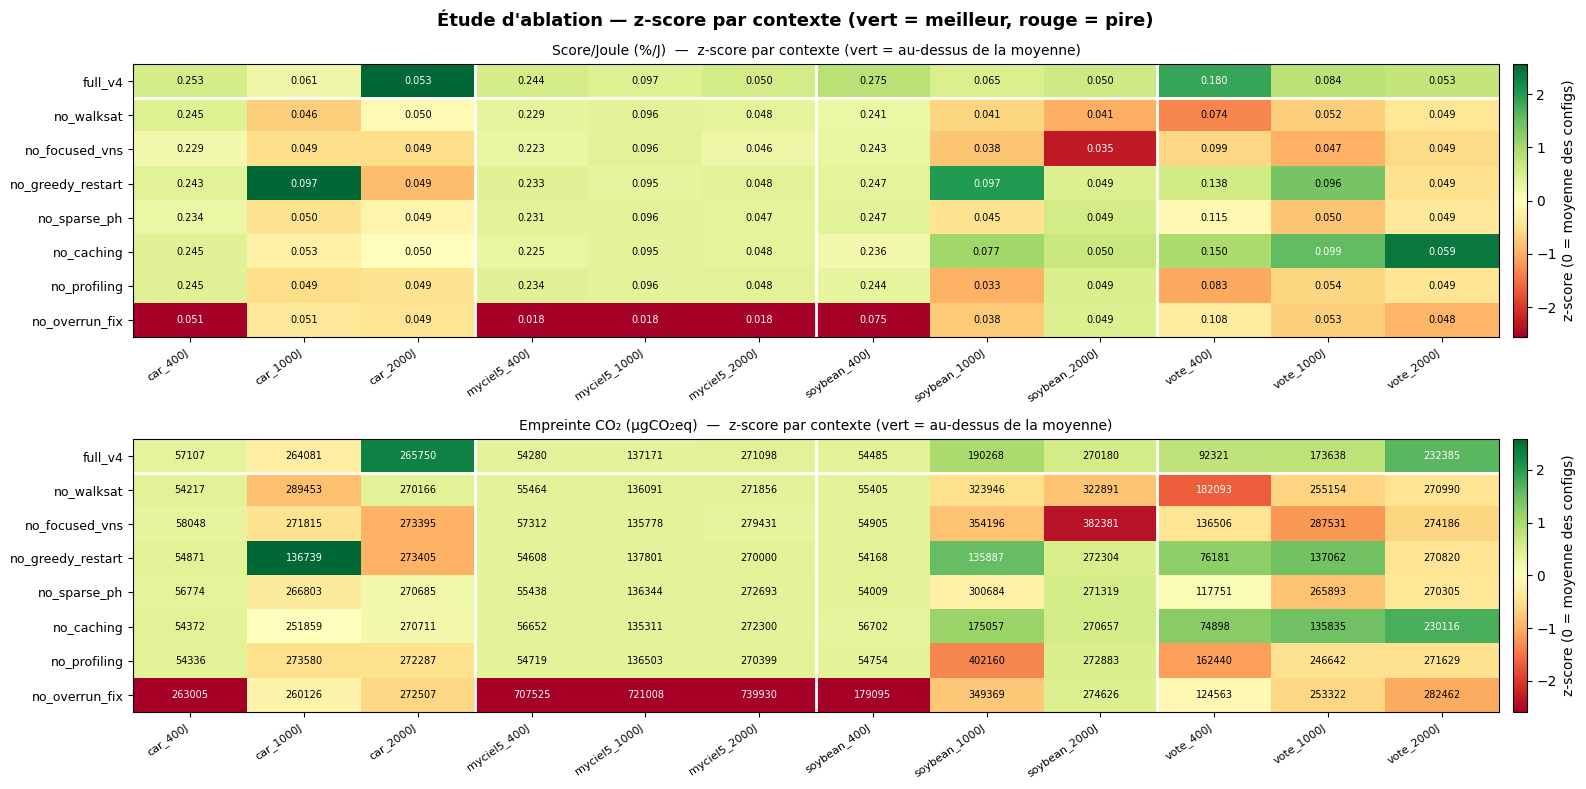

✔ Sauvegardé: fig_ablation.png


In [79]:
# ════════════════════════════════════════════════════════════════════
# CELLULE B — Visualiser les résultats d'ablation (z-score par contexte)
# ════════════════════════════════════════════════════════════════════

if os.path.exists("ablation_results.csv"):
    df_abl = pd.read_csv("ablation_results.csv")
    print(f"✔ ablation_results.csv — {len(df_abl)} lignes, configs : {df_abl['config'].unique()}")

    inst_map = {
        "decision-tree-soybean-un-formula_0.8_2021_atleast_15_max-3_reduced_incomplete_tree": "soybean",
        "min-fill-MinFill_R0_myciel5":                                                         "myciel5",
        "decision-tree-car-un-formula_0.8_2021_atleast_15_max-3_reduced_incomplete_tree":      "car",
        "decision-tree-vote-un-formula_0.8_2021_atleast_15_max-3_reduced_incomplete_tree":     "vote",
    }
    df_abl["inst_short"] = df_abl["instance"].map(inst_map).fillna(df_abl["instance"].str[:12])
    df_abl["context"]    = df_abl["inst_short"] + "_" + df_abl["budget_j"].astype(str) + "J"

    configs_order  = ["full_v4", "no_walksat", "no_focused_vns", "no_greedy_restart",
                      "no_sparse_ph", "no_caching", "no_profiling", "no_overrun_fix"]
    configs_order  = [c for c in configs_order if c in df_abl["config"].unique()]
    contexts_order = sorted(df_abl["context"].unique(),
                            key=lambda x: (x.rsplit("_", 1)[0], int(x.rsplit("_", 1)[-1].replace("J", ""))))

    metrics       = ["score_per_joule", "co2_micrograms"]
    metric_labels = ["Score/Joule (%/J)", "Empreinte CO₂ (μgCO₂eq)"]
    higher_better = [True, False]

    fmt_fn = {
        "score_per_joule": lambda v: f"{v:.3f}",
        "co2_micrograms":  lambda v: f"{v:.0f}",
    }

    def safe_get(series, key):
        try:
            val = series.loc[key]
            return float(val) if not isinstance(val, str) else np.nan
        except KeyError:
            return np.nan

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle("Étude d'ablation — z-score par contexte (vert = meilleur, rouge = pire)",
                 fontsize=13, fontweight="bold")

    for ax, metric, label, hb in zip(axes, metrics, metric_labels, higher_better):

        raw_matrix, annot = [], []
        for cfg in configs_order:
            sub = df_abl[df_abl["config"] == cfg].set_index("context")[metric]
            row_vals, row_ann = [], []
            for ctx in contexts_order:
                val = safe_get(sub, ctx)
                row_vals.append(val)
                row_ann.append(fmt_fn[metric](val) if not np.isnan(val) else "")
            raw_matrix.append(row_vals)
            annot.append(row_ann)

        raw_matrix = np.array(raw_matrix, dtype=float)

        col_mean = np.nanmean(raw_matrix, axis=0)
        col_std  = np.nanstd(raw_matrix, axis=0)
        col_std[col_std < 1e-9] = 1e-9

        z_matrix = (raw_matrix - col_mean) / col_std
        if not hb:
            z_matrix = -z_matrix

        vmax = max(np.nanpercentile(np.abs(z_matrix), 95), 0.1)
        im = ax.imshow(z_matrix, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

        for i in range(len(configs_order)):
            for j in range(len(contexts_order)):
                v = z_matrix[i, j]
                color = "white" if abs(v) > vmax * 0.6 else "black"
                ax.text(j, i, annot[i][j], ha="center", va="center", fontsize=7, color=color)

        ax.set_yticks(range(len(configs_order)))
        ax.set_yticklabels(configs_order, fontsize=9)
        ax.set_xticks(range(len(contexts_order)))
        ax.set_xticklabels(contexts_order, rotation=35, ha="right", fontsize=8)
        ax.set_title(f"{label}  —  z-score par contexte (vert = au-dessus de la moyenne)",
                     fontsize=10)

        for sep in range(3, len(contexts_order), 3):
            ax.axvline(sep - 0.5, color="white", linewidth=2)
        ax.axhline(0.5, color="white", linewidth=2)

        plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01,
                     label="z-score (0 = moyenne des configs)")

    plt.tight_layout()
    plt.savefig("fig_ablation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✔ Sauvegardé: fig_ablation.png")

else:
    print("⚠ ablation_results.csv non trouvé — exécuter la cellule A d'abord")

# 3. Rappel — Baselines TP4

## 3.1 AG

| Variante | Sélection | Croisement | Mutation | Spécificité |
|---|---|---|---|---|
| **AG Classique** | Tournoi binaire (k=2) | 1-point, Pc=0.85 | Bit-flip, Pm=1/n | Élitisme (1 individu conservé) |
| **AG Adaptatif** | Tournoi binaire | 1-point | Bit-flip | Pc et Pm ajustés dynamiquement selon la convergence |
| **AG + Knowledge Compilation** | Tournoi binaire | 1-point | Bit-flip | Mémoïsation des évaluations partielles pour accélérer le calcul de fitness |

## 3.2 ACO 

| Variante | Référence | Mécanisme clé |
|---|---|---|
| **AS-SAT** | Dorigo et al. | Ant System standard : MAJ phéromone par toutes les fourmis|
| **AS-SAT Élitiste** | Dorigo et al. (1996) | Renforcement additionnel de la meilleure solution globale |
| **MMAS** | Stützle & Hoos (2000) | Bornes [τ_min, τ_max] strictes + seule la meilleure fourmi met à jour ; reset sur stagnation |
| **ACS** | Dorigo & Gambardella (1997) | Règle pseudo-aléatoire proportionnelle (q₀), MAJ locale en ligne + MAJ globale unique |


⚠ Méthodes timeout supprimées (green_metrics_aco_methods.csv) : ['NL-ACO', 'FACO']
✔ green_metrics_aco_methods.csv — 16 lignes, méthodes : ['AS-SAT' 'AS-SAT Elitiste' 'MMAS' 'ACS']
⚠ Méthodes timeout supprimées (green_metrics_ga_methods.csv) : ['AG + Loc.Search']
✔ green_metrics_ga_methods.csv — 12 lignes, méthodes : ['AG Classique' 'AG Adaptatif' 'AG + KC']

 Résumé baseline — qualité et énergie par méthode :


,method,qualite_moy,qualite_std,energie_moy_j,qj_ratio,co2_moy
0,ACS,95.454000,1.900000,5562.728000,0.018000,750968.248000
1,AG + KC,89.121000,1.288000,4278.389000,0.021000,577582.458000
2,AG Adaptatif,89.450000,3.190000,6610.772000,0.015000,892454.203000
3,AG Classique,89.508000,2.005000,4171.609000,0.021000,563167.261000
4,AS-SAT,95.149000,0.964000,6320.699000,0.016000,853294.337000
5,AS-SAT Elitiste,95.414000,0.820000,5703.388000,0.018000,769957.337000
6,MMAS,94.464000,1.411000,6265.251000,0.016000,845808.926000


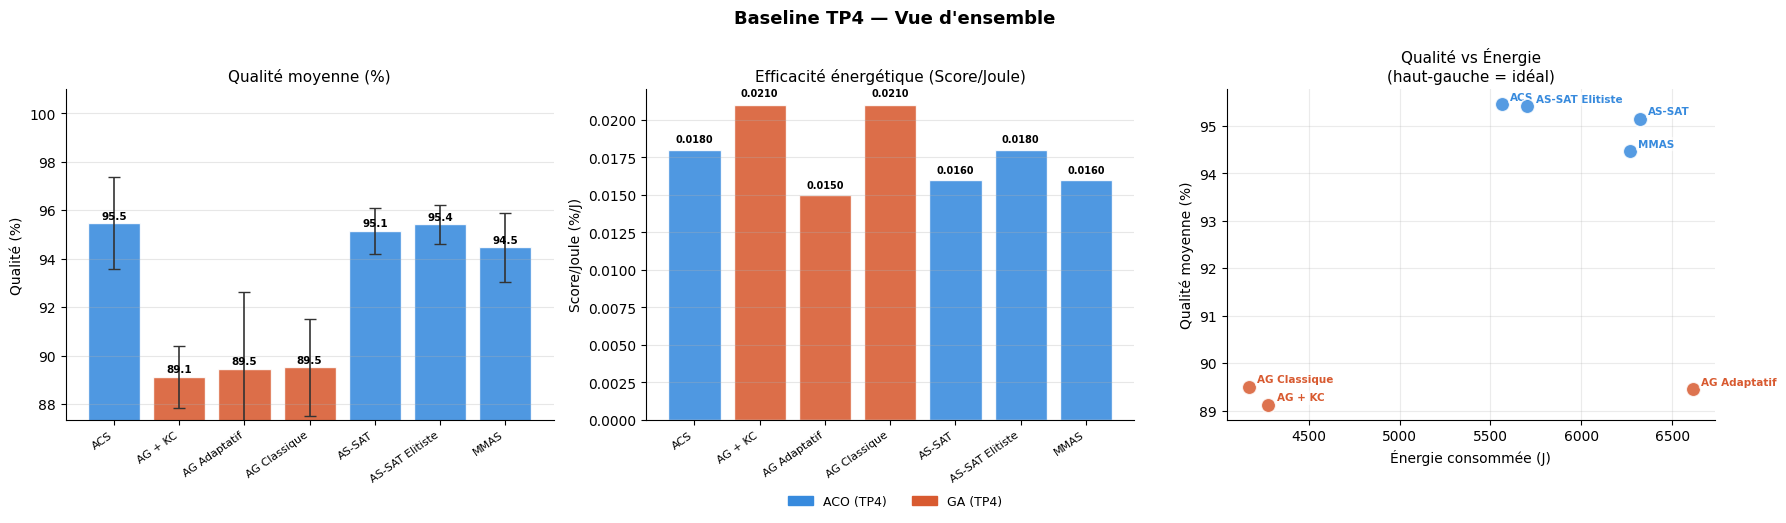

✔ Sauvegardé : fig_baseline_overview.png


In [29]:
# ── Charger les résultats de la baseline TP4 ─────────────────────────────────

baseline_files = {
    "ACO (TP4)": "green_metrics_aco_methods.csv",
    "GA (TP4)" : "green_metrics_ga_methods.csv",
}

dfs_baseline = {}
for label, fname in baseline_files.items():
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        timed_out = df[df["timeout"] == True]["method"].unique()
        if len(timed_out):
            print(f"⚠ Méthodes timeout supprimées ({fname}) : {list(timed_out)}")
        df = df[df["timeout"] != True]
        dfs_baseline[label] = df
        print(f"✔ {fname} — {len(df)} lignes, méthodes : {df['method'].unique()}")
    else:
        print(f"⚠ {fname} non trouvé")

if dfs_baseline:
    df_all_baseline = pd.concat(dfs_baseline.values(), ignore_index=True)

    # ── Résumé tabulaire ─────────────────────────────────────────────────────
    print("\n Résumé baseline — qualité et énergie par méthode :")
    summary_bl = df_all_baseline.groupby("method").agg(
        qualite_moy   = ("qualite_pct",      "mean"),
        qualite_std   = ("qualite_pct",      "std"),
        energie_moy_j = ("energie_joules",   "mean"),
        qj_ratio      = ("score_per_joule",  "mean"),
        co2_moy       = ("co2_micrograms",   "mean"),
    ).round(3).reset_index()
    display(summary_bl.style
            .background_gradient(subset=["qualite_moy"], cmap="YlGn")
            .background_gradient(subset=["qj_ratio"],    cmap="Blues")
            .set_caption("Baseline TP4 — agrégé sur toutes les instances"))

    # ── Visualisations ───────────────────────────────────────────────────────
    FAMILY_COLORS = {
        "ACO (TP4)": "#378ADD",
        "GA (TP4)":  "#D85A30",
    }
    # Associer chaque méthode à sa famille pour la couleur
    method_family = {}
    for label, df in dfs_baseline.items():
        for m in df["method"].unique():
            method_family[m] = label

    methods     = summary_bl["method"].tolist()
    bar_colors  = [FAMILY_COLORS[method_family[m]] for m in methods]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Baseline TP4 — Vue d'ensemble", fontsize=13, fontweight="bold")

    # ── 1. Qualité moyenne par méthode ───────────────────────────────────────
    ax = axes[0]
    bars = ax.bar(methods, summary_bl["qualite_moy"], color=bar_colors, alpha=0.88, edgecolor="white")
    ax.set_title("Qualité moyenne (%)", fontsize=11)
    ax.set_ylabel("Qualité (%)")
    ax.set_ylim(summary_bl["qualite_moy"].min() * 0.98, 101)
    ax.set_xticklabels(methods, rotation=35, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    # Barres d'erreur (std)
    ax.errorbar(methods, summary_bl["qualite_moy"], yerr=summary_bl["qualite_std"],
                fmt="none", color="#333", capsize=4, linewidth=1.2)
    for bar, val in zip(bars, summary_bl["qualite_moy"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{val:.1f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

    # ── 2. Ratio Score/Joule ─────────────────────────────────────────────────
    ax = axes[1]
    bars = ax.bar(methods, summary_bl["qj_ratio"], color=bar_colors, alpha=0.88, edgecolor="white")
    ax.set_title("Efficacité énergétique (Score/Joule)", fontsize=11)
    ax.set_ylabel("Score/Joule (%/J)")
    ax.set_xticklabels(methods, rotation=35, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, summary_bl["qj_ratio"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f"{val:.4f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

    # ── 3. Scatter qualité vs énergie ────────────────────────────────────────
    ax = axes[2]
    for _, row in summary_bl.iterrows():
        c = FAMILY_COLORS[method_family[row["method"]]]
        ax.scatter(row["energie_moy_j"], row["qualite_moy"],
                   color=c, s=110, alpha=0.85, edgecolors="white", linewidth=1.2, zorder=3)
        ax.annotate(row["method"],
                    (row["energie_moy_j"], row["qualite_moy"]),
                    textcoords="offset points", xytext=(6, 3),
                    fontsize=7.5, color=c, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))
    ax.set_xlabel("Énergie consommée (J)")
    ax.set_ylabel("Qualité moyenne (%)")
    ax.set_title("Qualité vs Énergie\n(haut-gauche = idéal)", fontsize=11)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    # Légende famille
    legend_handles = [
        mpatches.Patch(color=FAMILY_COLORS["ACO (TP4)"], label="ACO (TP4)"),
        mpatches.Patch(color=FAMILY_COLORS["GA (TP4)"],  label="GA (TP4)"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    plt.savefig("fig_baseline_overview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✔ Sauvegardé : fig_baseline_overview.png")

else:
    print("\nℹ Les fichiers CSV de la baseline seront chargés quand disponibles.")
    print("  Noms attendus : green_metrics_aco_methods.csv et green_metrics_ga_methods.csv")

---
# 4. Résultats Comparatifs

## 4.1 Comparaison Green ACO v4 vs Baseline (bar charts)


In [81]:
# ── Charger Green ACO v4 ──────────────────────────────────────────────────────

TP5_FILES = ["best_params_results.csv"]

df_tp5 = None
for fname in TP5_FILES:
    if os.path.exists(fname):
        df_tp5 = pd.read_csv(fname)
        df_tp5["method"] = "Green ACO v4"
        print(f"✔ {fname} chargé pour Green ACO v4 — {len(df_tp5)} lignes")
        break

if df_tp5 is None:
    print("⚠ Aucun fichier de résultats Green ACO v4 trouvé")
    print("  Fichiers cherchés :", TP5_FILES)

✔ best_params_results.csv chargé pour Green ACO v4 — 12 lignes


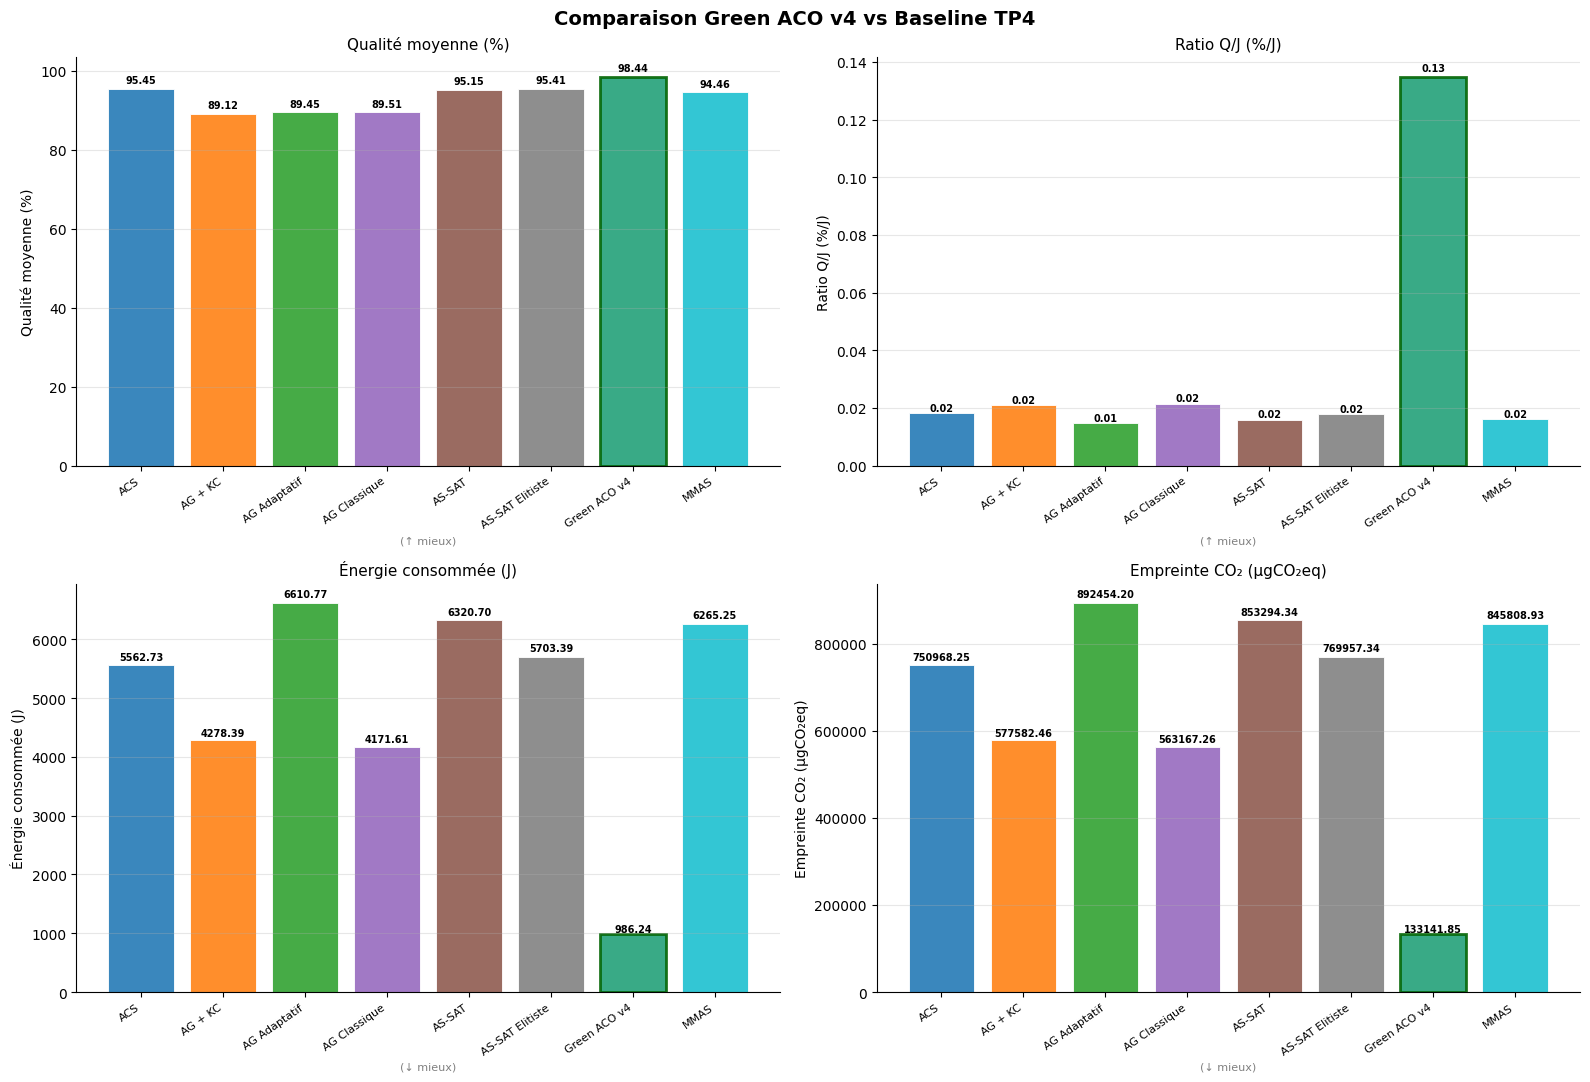

✔ Sauvegardé: fig_comparison_methods.png


In [82]:
# ── Bar charts de comparaison ─────────────────────────────────────────────────

if df_tp5 is not None and dfs_baseline:
    # Harmoniser les colonnes
    COLS_COMMON = ["method", "qualite_pct", "energie_joules", "score_per_joule", "co2_micrograms"]
    
    # Renommer colonnes TP5 si nécessaire
    if "qualite_pct" not in df_tp5.columns and "qualite_solution" in df_tp5.columns:
        df_tp5["qualite_pct"] = df_tp5["qualite_solution"] / df_tp5["n_clauses"] * 100
    
    dfs_all = []
    for lbl, df_b in dfs_baseline.items():
        dfs_all.append(df_b[COLS_COMMON].copy())
    dfs_all.append(df_tp5[COLS_COMMON].copy())
    df_compare = pd.concat(dfs_all, ignore_index=True)
    
    methods = df_compare["method"].unique()
    agg_cmp = df_compare.groupby("method")[["qualite_pct","score_per_joule","energie_joules","co2_micrograms"]].mean()
    
    METRICS_CMP = [
        ("qualite_pct",     "Qualité moyenne (%)",       True,  "YlGn"),
        ("score_per_joule", "Ratio Q/J (%/J)",           True,  "Blues"),
        ("energie_joules",  "Énergie consommée (J)",     False, "YlOrRd"),
        ("co2_micrograms",  "Empreinte CO₂ (μgCO₂eq)",  False, "Oranges"),
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle("Comparaison Green ACO v4 vs Baseline TP4", fontsize=14, fontweight="bold")
    
    palette_methods = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    color_map = {m: palette_methods[i] for i, m in enumerate(sorted(methods))}
    # Mettre Green ACO v4 en évidence
    color_map["Green ACO v4"] = "#1D9E75"
    
    for ax, (metric, label, hb, _) in zip(axes.flat, METRICS_CMP):
        vals = [agg_cmp.loc[m, metric] if m in agg_cmp.index else 0 for m in sorted(methods)]
        method_names = sorted(methods)
        bars = ax.bar(method_names, vals,
                      color=[color_map[m] for m in method_names],
                      alpha=0.88, edgecolor="white", linewidth=0.7)
        
        # Surligner Green ACO v4
        if "Green ACO v4" in method_names:
            idx = method_names.index("Green ACO v4")
            bars[idx].set_edgecolor("darkgreen")
            bars[idx].set_linewidth(2)
        
        ax.set_title(label, fontsize=11)
        ax.set_xticklabels(method_names, rotation=35, ha="right", fontsize=8)
        ax.set_ylabel(label)
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)
        note = "(↑ mieux)" if hb else "(↓ mieux)"
        ax.set_xlabel(note, fontsize=8, color="gray")
        
        # Annotation valeurs
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("fig_comparison_methods.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✔ Sauvegardé: fig_comparison_methods.png")
else:
    print("ℹ En attente des fichiers CSV (baseline + résultats TP5)")


## 4.2 Vitesse de convergence

La vitesse de convergence est visualisée à partir du fichier `best_params_results.csv` ou `green_aco_results_v3.csv` qui contiennent `nb_iterations` et `qualite_pct` par budget.


✔ best_params_results.csv — colonnes : ['instance', 'budget_j', 'qualite_pct', 'energie_joules', 'budget_utilise_pct', 'score_per_joule', 'co2_micrograms', 'pheromone_savings_pct', 'stopped_reason', 'nb_iterations', 'variant']


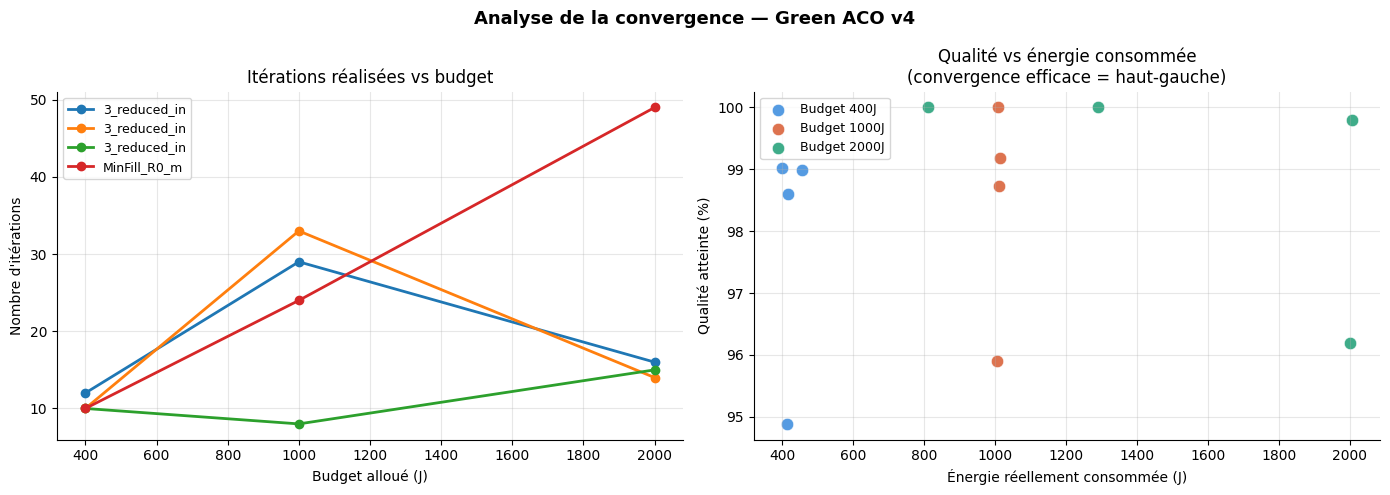

✔ Sauvegardé: fig_convergence.png


In [83]:
# ── Courbes de convergence ────────────────────────────────────────────────────
# Utilise best_params_results.csv (contient nb_iterations, stopped_reason)

conv_file = None
for fname in ["best_params_results.csv"]:
    if os.path.exists(fname):
        conv_file = fname
        break

if conv_file:
    df_conv = pd.read_csv(conv_file)
    print(f"✔ {conv_file} — colonnes : {list(df_conv.columns)}")
    
    # Si on a les données historiques d'évolution
    if "nb_iterations" in df_conv.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("Analyse de la convergence — Green ACO v4", fontsize=13, fontweight="bold")
        
        # ── Nb itérations vs budget ──────────────────────────────────────────
        ax = axes[0]
        if "instance" in df_conv.columns:
            for inst_name, grp in df_conv.groupby("instance"):
                short = inst_name.split("-")[-1][:12]
                x = grp["budget_j"] if "budget_j" in grp else grp["energie_joules"]
                ax.plot(x, grp["nb_iterations"], marker="o", label=short, linewidth=2)
        else:
            ax.bar(range(len(df_conv)), df_conv["nb_iterations"], color="#378ADD", alpha=0.8)
        ax.set_xlabel("Budget alloué (J)")
        ax.set_ylabel("Nombre d'itérations")
        ax.set_title("Itérations réalisées vs budget")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)
        
        # ── Qualité atteinte vs énergie réellement consommée ─────────────────
        ax = axes[1]
        budgets_list = sorted(df_conv["budget_j"].unique()) if "budget_j" in df_conv.columns else [400,1000,2000]
        COLORS_B = {400: "#378ADD", 1000: "#D85A30", 2000: "#1D9E75"}
        
        for budget in budgets_list:
            sub = df_conv[df_conv["budget_j"] == budget] if "budget_j" in df_conv.columns else df_conv
            ax.scatter(sub["energie_joules"], sub["qualite_pct"],
                       color=COLORS_B.get(budget, "#888"), s=80, alpha=0.85,
                       label=f"Budget {budget}J", edgecolors="white", linewidth=0.5)
        
        ax.set_xlabel("Énergie réellement consommée (J)")
        ax.set_ylabel("Qualité atteinte (%)")
        ax.set_title("Qualité vs énergie consommée\n(convergence efficace = haut-gauche)")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)
        
        plt.tight_layout()
        plt.savefig("fig_convergence.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("✔ Sauvegardé: fig_convergence.png")

elif dfs_baseline:
    # Proxy : utiliser nb_mouvements_ameliorants comme indicateur de convergence
    print("ℹ best_params_results.csv non trouvé — utilisation des données baseline")
    fig, ax = plt.subplots(figsize=(10, 5))
    
    df_b = list(dfs_baseline.values())[0]
    if "nbr_mouvements_ameliorants" in df_b.columns:
        for method, grp in df_b.groupby("method"):
            ax.bar(method, grp["nbr_mouvements_ameliorants"].mean(), alpha=0.8)
        ax.set_ylabel("Mouvements améliorants moyens")
        ax.set_title("Dynamique de recherche — baseline TP4")
        ax.tick_params(axis="x", rotation=30)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("ℹ Fichiers de résultats non disponibles — relancer les expériences")


---
# 5. Interprétation et Comparaison Globale

## 5.1 Synthèse des résultats

Cette section analyse les résultats selon trois axes : **qualité de solution**, **efficacité énergétique**, et **empreinte carbone**.


In [86]:
# ── Table de synthèse finale ──────────────────────────────────────────────────

rows_synth = []

if df_tp5 is not None:
    rows_synth.append({
        "Méthode"         : "Green ACO",
        "Famille"         : "ACO + EI/J Scheduler",
        "Qualité moy. (%)" : df_tp5["qualite_pct"].mean() if "qualite_pct" in df_tp5.columns else "—",
        "Score/Joule"     : df_tp5["score_per_joule"].mean() if "score_per_joule" in df_tp5.columns else "—",
        "Énergie (J)"     : df_tp5["energie_joules"].mean() if "energie_joules" in df_tp5.columns else "—",
        "CO₂ (μg)"        : df_tp5["co2_micrograms"].mean() if "co2_micrograms" in df_tp5.columns else "—",
        "Rang global"     : "—",
    })

for lbl, df_b in dfs_baseline.items():
    for method, grp in df_b.groupby("method"):
        rows_synth.append({
            "Méthode"          : method,
            "Famille"          : lbl,
            "Qualité moy. (%)": grp["qualite_pct"].mean() if "qualite_pct" in grp else "—",
            "Score/Joule"      : grp["score_per_joule"].mean() if "score_per_joule" in grp else "—",
            "Énergie (J)"      : grp["energie_joules"].mean() if "energie_joules" in grp else "—",
            "CO₂ (μg)"         : grp["co2_micrograms"].mean() if "co2_micrograms" in grp else "—",
            "Rang global"      : "—",
        })

if rows_synth:
    df_synth = pd.DataFrame(rows_synth)
    
    # Calculer le rang sur Score/Joule
    numeric_mask = df_synth["Score/Joule"].apply(lambda x: isinstance(x, (int, float)))
    df_synth.loc[numeric_mask, "Rang global"] = df_synth.loc[numeric_mask, "Score/Joule"].rank(ascending=False).astype(int)
    
    # Arrondir les valeurs numériques
    for col in ["Qualité moy. (%)", "Score/Joule", "Énergie (J)", "CO₂ (μg)"]:
        df_synth[col] = pd.to_numeric(df_synth[col], errors="coerce").round(4)
    
    df_synth = df_synth.sort_values("Score/Joule", ascending=False, na_position="last")
    
    print("Classement final — toutes méthodes (trié par Score/Joule)")
    display(df_synth.style
            .background_gradient(subset=pd.IndexSlice[:, ["Score/Joule"]], cmap="Blues")
            .background_gradient(subset=pd.IndexSlice[:, ["Qualité moy. (%)"]], cmap="YlGn")
            .applymap(lambda v: "font-weight: bold; background-color: #d4edda" 
                      if v == "Green ACO" else "", subset=["Méthode"])
            .set_caption("Comparaison globale — Green ACO v4 vs Baseline TP4"))
else:
    print("ℹ Aucune donnée disponible — charger les fichiers CSV de résultats")


Classement final — toutes méthodes (trié par Score/Joule)


,Méthode,Famille,Qualité moy. (%),Score/Joule,Énergie (J),CO₂ (μg),Rang global
0,Green ACO,ACO + EI/J Scheduler,98.440900,0.134800,986.236000,133141.853700,1
7,AG Classique,GA (TP4),89.508000,0.021500,4171.609300,563167.261400,2
5,AG + KC,GA (TP4),89.121100,0.020900,4278.388600,577582.457600,3
1,ACS,ACO (TP4),95.454200,0.018200,5562.727800,750968.248500,4
3,AS-SAT Elitiste,ACO (TP4),95.413700,0.017900,5703.387700,769957.337100,5
4,MMAS,ACO (TP4),94.464400,0.016100,6265.251300,845808.926100,6
2,AS-SAT,ACO (TP4),95.149500,0.015900,6320.698800,853294.336700,7
6,AG Adaptatif,GA (TP4),89.449800,0.014700,6610.771900,892454.202600,8


## 5.2 Analyse et conclusions

* Green ACO montre qu'intégrer la conscience énergétique au niveau de la sélection d'opérateurs produit un algorithme plus efficace et plus fiable par rapport aux algos standards. Plusieurs observations ressortent de l'étude d'ablation.

* **`clause_restart_greedy` est le composant le plus risqué sans garde.** Il produit des sauts de qualité massifs (+1000 à +3700 Δf par appel) mais son coût est très élevé (800–3600J selon l'instance). Sans `max_overrun_factor`, `no_overrun_fix` consomme jusqu'à 5241J sur myciel5/400J — soit +1210% du budget alloué. C'est l'ablation la plus catastrophique observée, et elle valide à elle seule la nécessité de la garde anti-dépassement.

* **L'ordonnanceur EI/J justifie son coût sur budgets contraints.** À 400J, `full` dépasse les ablations sur vote et myciel5 en ratio score/joule, précisément les instances où les opérateurs ont des profils de coût très hétérogènes et où le scheduler doit vraiment arbitrer. À 1000J et 2000J les écarts s'estompent car toutes les configs convergent vers ~99% de qualité.

* **La suppression de WalkSAT dégrade surtout l'instance vote.** À 400J, `no_walksat` chute à 0.074 score/joule contre 0.180 pour `full` — vote est une instance à très peu de clauses non satisfaites (best known = 6), exactement le régime où WalkSAT excelle : cibler chirurgicalement les rares clauses restantes est plus rentable que toute reconstruction globale.

* **Le frugal skip et l'évaporation adaptative limitent les mises à jour inutiles.** En phase de stagnation, éviter de renforcer des solutions qui ne progressent pas préserve la diversité de la matrice de phéromones, 17 à 27% des mises à jour économisées sans perte de qualité mesurable sur soybean et car.

* **min-fill reste l'instance la plus difficile quelle que soit la configuration.** Sa densité de clauses (109 371 pour 15 416 variables) limite mécaniquement le nombre d'itérations disponibles par budget, réduisant l'avantage de tout mécanisme d'apprentissage adaptatif.

* **L'arrêt anticipé est l'économie la plus silencieuse.** Sur vote/2000J, le plateau 99.5% est atteint bien avant l'épuisement du budget — jusqu'à 574J non consommés, soit une réduction directe de l'empreinte CO₂ sans aucun compromis sur la qualité finale.


